In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image

In [2]:
model = tf.keras.models.load_model(
    "../models/vgg16_pneumonia.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [3]:
image_path = "../data/test/PNEUMONIA/person1_virus_6.jpeg"

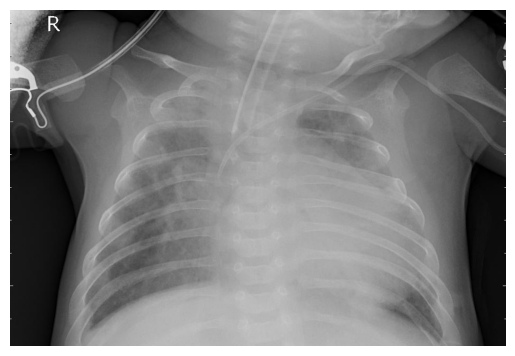

In [4]:
img = image.load_img(image_path)

plt.imshow(img)
plt.axis("off")

plt.show()

In [5]:
img = image.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

print(img_array.shape)

(1, 224, 224, 3)


In [6]:
prediction = model.predict(img_array)

prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step


array([[0.99997896]], dtype=float32)

In [7]:
probability = prediction[0][0]

if probability >= 0.5:
    label = "PNEUMONIA"
else:
    label = "NORMAL"

print("Prediction:", label)
print("Confidence:", round(probability * 100, 2), "%")

Prediction: PNEUMONIA
Confidence: 100.0 %


In [8]:
def predict_xray(image_path, model):

    img = image.load_img(
        image_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = model.predict(
        img_array,
        verbose=0
    )

    probability = prediction[0][0]

    if probability >= 0.5:
        label = "PNEUMONIA"
    else:
        label = "NORMAL"

    print("Prediction:", label)
    print(
        "Confidence:",
        round(probability * 100, 2),
        "%"
    )

    return label, probability

In [9]:
predict_xray(
    image_path,
    model
)


Prediction: PNEUMONIA
Confidence: 100.0 %


('PNEUMONIA', np.float32(0.99997896))

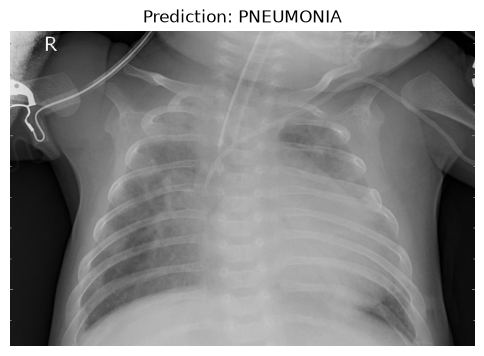

In [10]:
img = image.load_img(image_path)

plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title(
    f"Prediction: {label}"
)

plt.axis("off")

plt.show()

In [13]:
image_path = "../data/test/NORMAL/IM-0001-0001.jpeg"

predict_xray(image_path, model)

Prediction: PNEUMONIA
Confidence: 100.0 %


('PNEUMONIA', np.float32(0.9999787))

In [21]:
import tensorflow as tf

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False,
    label_mode="binary"
)

print(test_dataset.class_names)

Found 624 files belonging to 2 classes.
['NORMAL', 'PNEUMONIA']


In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    preds = model.predict(images, verbose=0)

    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy().astype(int).flatten())
    y_pred.extend(preds.flatten())

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[147  87]
 [  6 384]]
              precision    recall  f1-score   support

           0       0.96      0.63      0.76       234
           1       0.82      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.84       624



In [ ]:
import os

normal_folder = "../data/test/NORMAL"

correct_normal = []

for file in os.listdir(normal_folder):

    image_path = os.path.join(normal_folder, file)

    img = image.load_img(
        image_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)
    # img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0][0]

    if pred < 0.5:
        correct_normal.append(file)

print("Correctly classified NORMAL images:")
print(correct_normal[:20])
print("Total:", len(correct_normal))

Correctly classified NORMAL images:
[]
Total: 0
